In [1]:
# Install dependencies
!pip install scikit-image scikit-learn torch torchvision matplotlib seaborn pandas tqdm -q
# Caltech-101 via torchvision (requires downloading)
print('Installation complete.')

Installation complete.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from scipy.stats import skew, kurtosis, pearsonr
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from skimage.feature import local_binary_pattern
from skimage.transform import resize as sk_resize

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

np.random.seed(42)
torch.manual_seed(42)

Device: cpu


In [3]:
# ── Intra-color ──────────────────────────────────────────────────────────────
def extract_intra_color(img_rgb):
    """
    Per-channel statistics: mean, std, skewness, kurtosis.
    img_rgb : HxWx3 float32 in [0,1]  (RGB)
    Returns  : 12-dim vector
    """
    feats = []
    for c in range(3):
        ch = img_rgb[:, :, c].ravel()
        feats += [np.mean(ch), np.std(ch), float(skew(ch)), float(kurtosis(ch))]
    return np.array(feats, dtype=np.float32)


# ── Mutual Information helper ─────────────────────────────────────────────────
def _mi(a, b, bins=32):
    a = (a * 255).astype(np.uint8).ravel()
    b = (b * 255).astype(np.uint8).ravel()
    h, _, _ = np.histogram2d(a, b, bins=bins)
    h = h / h.sum() + 1e-10
    hx = h.sum(1); hy = h.sum(0)
    return float(np.sum(h * np.log(h / (np.outer(hx, hy) + 1e-10) + 1e-10)))


# ── Inter-color ───────────────────────────────────────────────────────────────
def extract_inter_color(img_rgb):
    """
    Cross-channel: Pearson corr + Mutual Information for (R,G), (G,B), (R,B).
    img_rgb : HxWx3 float32 in [0,1]
    Returns  : 6-dim vector
    """
    R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    cRG, _ = pearsonr(R.ravel(), G.ravel())
    cGB, _ = pearsonr(G.ravel(), B.ravel())
    cRB, _ = pearsonr(R.ravel(), B.ravel())
    return np.array([cRG, cGB, cRB, _mi(R,G), _mi(G,B), _mi(R,B)], dtype=np.float32)


# ── LBP ──────────────────────────────────────────────────────────────────────
def extract_lbp(img_rgb, P=8, R=1, n_bins=64):
    gray = np.mean(img_rgb, axis=2)
    lbp  = local_binary_pattern(gray, P=P, R=R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, P+2), density=True)
    return hist.astype(np.float32)


# ── Batch wrappers ────────────────────────────────────────────────────────────
def batch_extract(fn, imgs, desc=''):
    return np.array([fn(img) for img in tqdm(imgs, desc=desc, leave=False)])


print('Feature extractors defined.')

Feature extractors defined.


In [4]:
# ── CNN feature extractor (ResNet-18, shared) ─────────────────────────────────
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
cnn_model = nn.Sequential(*list(resnet.children())[:-1])   # → [B, 512, 1, 1]
cnn_model.eval().to(device)

cnn_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

def extract_cnn_from_pil(pil_imgs, batch_size=64):
    """
    pil_imgs : list of PIL Images (RGB)
    Returns  : [N, 512] numpy array
    """
    feats = []
    for i in tqdm(range(0, len(pil_imgs), batch_size), desc='CNN', leave=False):
        batch = pil_imgs[i:i+batch_size]
        tensors = torch.stack([cnn_transform(img) for img in batch]).to(device)
        with torch.no_grad():
            out = cnn_model(tensors).squeeze(-1).squeeze(-1)
        feats.append(out.cpu().numpy())
    return np.vstack(feats)

print('CNN extractor ready.')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 97.9MB/s]


CNN extractor ready.


In [5]:
def retrieve(Q_feat, G_feat, k=10):
    nn_model = NearestNeighbors(n_neighbors=k, metric='cosine', algorithm='brute')
    nn_model.fit(normalize(G_feat, norm='l2'))
    _, idx = nn_model.kneighbors(normalize(Q_feat, norm='l2'))
    return idx


def metrics(q_labels, g_labels, top_k_idx, k=10):
    precs, recs, aps = [], [], []
    for qi, ret in enumerate(top_k_idx):
        ql   = q_labels[qi]
        rel  = (g_labels[ret] == ql).astype(int)
        tot  = max((g_labels == ql).sum(), 1)
        precs.append(rel.sum() / k)
        recs.append(rel.sum() / tot)
        ap = 0.0; nr = 0
        for rk, r in enumerate(rel, 1):
            if r: nr += 1; ap += nr / rk
        aps.append(ap / tot)
    return dict(Precision=np.mean(precs), Recall=np.mean(recs), mAP=np.mean(aps))


def run_experiments(Q_feats_dict, G_feats_dict, q_labels, g_labels, k=10):
    """
    Q_feats_dict / G_feats_dict: {method_name: feature_array}
    Returns DataFrame of results.
    """
    rows = []
    for name in Q_feats_dict:
        idx = retrieve(Q_feats_dict[name], G_feats_dict[name], k=k)
        m   = metrics(q_labels, g_labels, idx, k=k)
        rows.append({'Method': name, **{f'{kk}@{k}': round(v,4) for kk,v in m.items()},'mAP': round(m['mAP'],4)})
    df = pd.DataFrame(rows)
    # avoid duplicate mAP column
    if f'mAP@{k}' in df.columns:
        df = df.drop(columns=[f'mAP@{k}'])
    return df


def fuse(*feat_arrays):
    """L2-normalise each block, then concatenate."""
    return np.hstack([normalize(f, norm='l2') for f in feat_arrays])


print('Retrieval & metrics ready.')

Retrieval & metrics ready.


In [6]:
# Load MNIST
mnist_train = torchvision.datasets.MNIST('./data', train=True,  download=True)
mnist_test  = torchvision.datasets.MNIST('./data', train=False, download=True)

GALLERY_MNIST = 2000
QUERY_MNIST   = 300

g_idx_m = np.random.choice(len(mnist_train), GALLERY_MNIST, replace=False)
q_idx_m = np.random.choice(len(mnist_test),  QUERY_MNIST,   replace=False)

def load_mnist_as_rgb(dataset, indices):
    imgs_np, pil_imgs, labels = [], [], []
    for i in indices:
        pil, lbl = dataset[i]
        rgb = pil.convert('RGB')          # 28x28 grayscale → RGB (3 identical channels)
        arr = np.array(rgb, dtype=np.float32) / 255.0
        imgs_np.append(arr)
        pil_imgs.append(rgb)
        labels.append(lbl)
    return np.array(imgs_np), pil_imgs, np.array(labels)

Gm_np, Gm_pil, Gm_lbl = load_mnist_as_rgb(mnist_train, g_idx_m)
Qm_np, Qm_pil, Qm_lbl = load_mnist_as_rgb(mnist_test,  q_idx_m)
print(f'MNIST — Gallery: {Gm_np.shape}, Query: {Qm_np.shape}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 583kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.89MB/s]


MNIST — Gallery: (2000, 28, 28, 3), Query: (300, 28, 28, 3)


In [7]:
print('Extracting MNIST features...')
Gm_intra = batch_extract(extract_intra_color, Gm_np, 'MNIST Intra-Gallery')
Gm_inter = batch_extract(extract_inter_color, Gm_np, 'MNIST Inter-Gallery')
Gm_lbp   = batch_extract(extract_lbp,        Gm_np, 'MNIST LBP-Gallery')
Gm_cnn   = extract_cnn_from_pil(Gm_pil)

Qm_intra = batch_extract(extract_intra_color, Qm_np, 'MNIST Intra-Query')
Qm_inter = batch_extract(extract_inter_color, Qm_np, 'MNIST Inter-Query')
Qm_lbp   = batch_extract(extract_lbp,        Qm_np, 'MNIST LBP-Query')
Qm_cnn   = extract_cnn_from_pil(Qm_pil)
print('Done.')

Extracting MNIST features...


Done.


In [8]:
K = 10

Gm_color = fuse(Gm_intra, Gm_inter)
Qm_color = fuse(Qm_intra, Qm_inter)

G_mnist = {
    'Intra-Color':         Gm_intra,
    'Inter-Color':         Gm_inter,
    'Color (Intra+Inter)': Gm_color,
    'LBP':                 Gm_lbp,
    'CNN':                 Gm_cnn,
    'Color + LBP':         fuse(Gm_color, Gm_lbp),
    'Color + CNN':         fuse(Gm_color, Gm_cnn),
    'Color+LBP+CNN':       fuse(Gm_color, Gm_lbp, Gm_cnn),
}
Q_mnist = {
    'Intra-Color':         Qm_intra,
    'Inter-Color':         Qm_inter,
    'Color (Intra+Inter)': Qm_color,
    'LBP':                 Qm_lbp,
    'CNN':                 Qm_cnn,
    'Color + LBP':         fuse(Qm_color, Qm_lbp),
    'Color + CNN':         fuse(Qm_color, Qm_cnn),
    'Color+LBP+CNN':       fuse(Qm_color, Qm_lbp, Qm_cnn),
}

df_mnist = run_experiments(Q_mnist, G_mnist, Qm_lbl, Gm_lbl, k=K)
print('\n=== MNIST Results ===')
print(df_mnist.to_string(index=False))


=== MNIST Results ===
             Method  Precision@10  Recall@10    mAP
        Intra-Color        0.1857     0.0091 0.0052
        Inter-Color        0.2133     0.0104 0.0064
Color (Intra+Inter)        0.2363     0.0115 0.0073
                LBP        0.2727     0.0133 0.0089
                CNN        0.8363     0.0416 0.0394
        Color + LBP        0.2610     0.0127 0.0082
        Color + CNN        0.7967     0.0396 0.0371
      Color+LBP+CNN        0.7957     0.0396 0.0370


In [9]:
cifar_train = torchvision.datasets.CIFAR10('./data', train=True,  download=True)
cifar_test  = torchvision.datasets.CIFAR10('./data', train=False, download=True)

GALLERY_CIFAR = 2000
QUERY_CIFAR   = 300

g_idx_c = np.random.choice(len(cifar_train), GALLERY_CIFAR, replace=False)
q_idx_c = np.random.choice(len(cifar_test),  QUERY_CIFAR,   replace=False)

def load_cifar_as_rgb(dataset, indices):
    imgs_np, pil_imgs, labels = [], [], []
    for i in indices:
        pil, lbl = dataset[i]              # PIL RGB
        arr = np.array(pil, dtype=np.float32) / 255.0
        imgs_np.append(arr)
        pil_imgs.append(pil)
        labels.append(lbl)
    return np.array(imgs_np), pil_imgs, np.array(labels)

Gc_np, Gc_pil, Gc_lbl = load_cifar_as_rgb(cifar_train, g_idx_c)
Qc_np, Qc_pil, Qc_lbl = load_cifar_as_rgb(cifar_test,  q_idx_c)
print(f'CIFAR-10 — Gallery: {Gc_np.shape}, Query: {Qc_np.shape}')

100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


CIFAR-10 — Gallery: (2000, 32, 32, 3), Query: (300, 32, 32, 3)


In [10]:
print('Extracting CIFAR-10 features...')
Gc_intra = batch_extract(extract_intra_color, Gc_np, 'CIFAR Intra-Gallery')
Gc_inter = batch_extract(extract_inter_color, Gc_np, 'CIFAR Inter-Gallery')
Gc_lbp   = batch_extract(extract_lbp,        Gc_np, 'CIFAR LBP-Gallery')
Gc_cnn   = extract_cnn_from_pil(Gc_pil)

Qc_intra = batch_extract(extract_intra_color, Qc_np, 'CIFAR Intra-Query')
Qc_inter = batch_extract(extract_inter_color, Qc_np, 'CIFAR Inter-Query')
Qc_lbp   = batch_extract(extract_lbp,        Qc_np, 'CIFAR LBP-Query')
Qc_cnn   = extract_cnn_from_pil(Qc_pil)
print('Done.')

Extracting CIFAR-10 features...


Done.


In [11]:
Gc_color = fuse(Gc_intra, Gc_inter)
Qc_color = fuse(Qc_intra, Qc_inter)

G_cifar = {
    'Intra-Color':         Gc_intra,
    'Inter-Color':         Gc_inter,
    'Color (Intra+Inter)': Gc_color,
    'LBP':                 Gc_lbp,
    'CNN':                 Gc_cnn,
    'Color + LBP':         fuse(Gc_color, Gc_lbp),
    'Color + CNN':         fuse(Gc_color, Gc_cnn),
    'Color+LBP+CNN':       fuse(Gc_color, Gc_lbp, Gc_cnn),
}
Q_cifar = {
    'Intra-Color':         Qc_intra,
    'Inter-Color':         Qc_inter,
    'Color (Intra+Inter)': Qc_color,
    'LBP':                 Qc_lbp,
    'CNN':                 Qc_cnn,
    'Color + LBP':         fuse(Qc_color, Qc_lbp),
    'Color + CNN':         fuse(Qc_color, Qc_cnn),
    'Color+LBP+CNN':       fuse(Qc_color, Qc_lbp, Qc_cnn),
}

df_cifar = run_experiments(Q_cifar, G_cifar, Qc_lbl, Gc_lbl, k=K)
print('\n=== CIFAR-10 Results ===')
print(df_cifar.to_string(index=False))


=== CIFAR-10 Results ===
             Method  Precision@10  Recall@10    mAP
        Intra-Color        0.1553     0.0077 0.0035
        Inter-Color        0.1497     0.0074 0.0033
Color (Intra+Inter)        0.1587     0.0079 0.0039
                LBP        0.1823     0.0089 0.0042
                CNN        0.6303     0.0315 0.0267
        Color + LBP        0.1847     0.0091 0.0048
        Color + CNN        0.4717     0.0235 0.0184
      Color+LBP+CNN        0.4710     0.0235 0.0183


In [12]:
# Download Caltech-101 via torchvision
# Note: requires ~130 MB download
caltech = torchvision.datasets.Caltech101(
    root='./data',
    target_type='category',
    download=True
)
print(f'Caltech-101 total images: {len(caltech)}')
print(f'Number of categories: {len(caltech.categories)}')

100%|██████████| 137M/137M [00:04<00:00, 29.2MB/s]


Caltech-101 total images: 8677
Number of categories: 101


In [13]:
# Sample gallery and query from Caltech-101
GALLERY_CAL = 1500
QUERY_CAL   = 200

all_idx = np.random.permutation(len(caltech))
g_idx_cal = all_idx[:GALLERY_CAL]
q_idx_cal = all_idx[GALLERY_CAL:GALLERY_CAL + QUERY_CAL]

def load_caltech_as_rgb(dataset, indices, target_size=(64, 64)):
    imgs_np, pil_imgs, labels = [], [], []
    for i in tqdm(indices, desc='Loading Caltech', leave=False):
        pil, lbl = dataset[i]
        pil = pil.convert('RGB')                       # some images are grayscale
        pil = pil.resize(target_size, Image.BILINEAR)  # resize to fixed size
        arr = np.array(pil, dtype=np.float32) / 255.0
        imgs_np.append(arr)
        pil_imgs.append(pil)
        labels.append(lbl)
    return np.array(imgs_np), pil_imgs, np.array(labels)

Gk_np, Gk_pil, Gk_lbl = load_caltech_as_rgb(caltech, g_idx_cal)
Qk_np, Qk_pil, Qk_lbl = load_caltech_as_rgb(caltech, q_idx_cal)
print(f'Caltech-101 — Gallery: {Gk_np.shape}, Query: {Qk_np.shape}')

Caltech-101 — Gallery: (1500, 64, 64, 3), Query: (200, 64, 64, 3)


In [14]:
print('Extracting Caltech-101 features...')
Gk_intra = batch_extract(extract_intra_color, Gk_np, 'Cal Intra-Gallery')
Gk_inter = batch_extract(extract_inter_color, Gk_np, 'Cal Inter-Gallery')
Gk_lbp   = batch_extract(extract_lbp,        Gk_np, 'Cal LBP-Gallery')
Gk_cnn   = extract_cnn_from_pil(Gk_pil)

Qk_intra = batch_extract(extract_intra_color, Qk_np, 'Cal Intra-Query')
Qk_inter = batch_extract(extract_inter_color, Qk_np, 'Cal Inter-Query')
Qk_lbp   = batch_extract(extract_lbp,        Qk_np, 'Cal LBP-Query')
Qk_cnn   = extract_cnn_from_pil(Qk_pil)
print('Done.')

Extracting Caltech-101 features...


Done.


In [15]:
Gk_color = fuse(Gk_intra, Gk_inter)
Qk_color = fuse(Qk_intra, Qk_inter)

G_caltech = {
    'Intra-Color':         Gk_intra,
    'Inter-Color':         Gk_inter,
    'Color (Intra+Inter)': Gk_color,
    'LBP':                 Gk_lbp,
    'CNN':                 Gk_cnn,
    'Color + LBP':         fuse(Gk_color, Gk_lbp),
    'Color + CNN':         fuse(Gk_color, Gk_cnn),
    'Color+LBP+CNN':       fuse(Gk_color, Gk_lbp, Gk_cnn),
}
Q_caltech = {
    'Intra-Color':         Qk_intra,
    'Inter-Color':         Qk_inter,
    'Color (Intra+Inter)': Qk_color,
    'LBP':                 Qk_lbp,
    'CNN':                 Qk_cnn,
    'Color + LBP':         fuse(Qk_color, Qk_lbp),
    'Color + CNN':         fuse(Qk_color, Qk_cnn),
    'Color+LBP+CNN':       fuse(Qk_color, Qk_lbp, Qk_cnn),
}

df_caltech = run_experiments(Q_caltech, G_caltech, Qk_lbl, Gk_lbl, k=K)
print('\n=== Caltech-101 Results ===')
print(df_caltech.to_string(index=False))


=== Caltech-101 Results ===
             Method  Precision@10  Recall@10    mAP
        Intra-Color        0.1015     0.0207 0.0113
        Inter-Color        0.0775     0.0225 0.0123
Color (Intra+Inter)        0.1165     0.0266 0.0135
                LBP        0.1815     0.0305 0.0174
                CNN        0.5970     0.2800 0.2365
        Color + LBP        0.1800     0.0346 0.0198
        Color + CNN        0.4295     0.1416 0.1064
      Color+LBP+CNN        0.4110     0.1234 0.0932


In [16]:
def add_meta(df, dataset_name):
    df = df.copy()
    df.insert(0, 'Dataset', dataset_name)
    return df

df_all = pd.concat([
    add_meta(df_mnist,   'MNIST'),
    add_meta(df_cifar,   'CIFAR-10'),
    add_meta(df_caltech, 'Caltech-101'),
], ignore_index=True)

# Rename columns for clarity
df_all.columns = ['Dataset', 'Method', f'Precision@{K}', f'Recall@{K}', 'mAP']

print('\n' + '='*90)
print('   FULL COMPARATIVE ANALYSIS TABLE — All Datasets')
print('='*90)
print(df_all.to_string(index=False))
print('='*90)


   FULL COMPARATIVE ANALYSIS TABLE — All Datasets
    Dataset              Method  Precision@10  Recall@10    mAP
      MNIST         Intra-Color        0.1857     0.0091 0.0052
      MNIST         Inter-Color        0.2133     0.0104 0.0064
      MNIST Color (Intra+Inter)        0.2363     0.0115 0.0073
      MNIST                 LBP        0.2727     0.0133 0.0089
      MNIST                 CNN        0.8363     0.0416 0.0394
      MNIST         Color + LBP        0.2610     0.0127 0.0082
      MNIST         Color + CNN        0.7967     0.0396 0.0371
      MNIST       Color+LBP+CNN        0.7957     0.0396 0.0370
   CIFAR-10         Intra-Color        0.1553     0.0077 0.0035
   CIFAR-10         Inter-Color        0.1497     0.0074 0.0033
   CIFAR-10 Color (Intra+Inter)        0.1587     0.0079 0.0039
   CIFAR-10                 LBP        0.1823     0.0089 0.0042
   CIFAR-10                 CNN        0.6303     0.0315 0.0267
   CIFAR-10         Color + LBP        0.1847     0.0

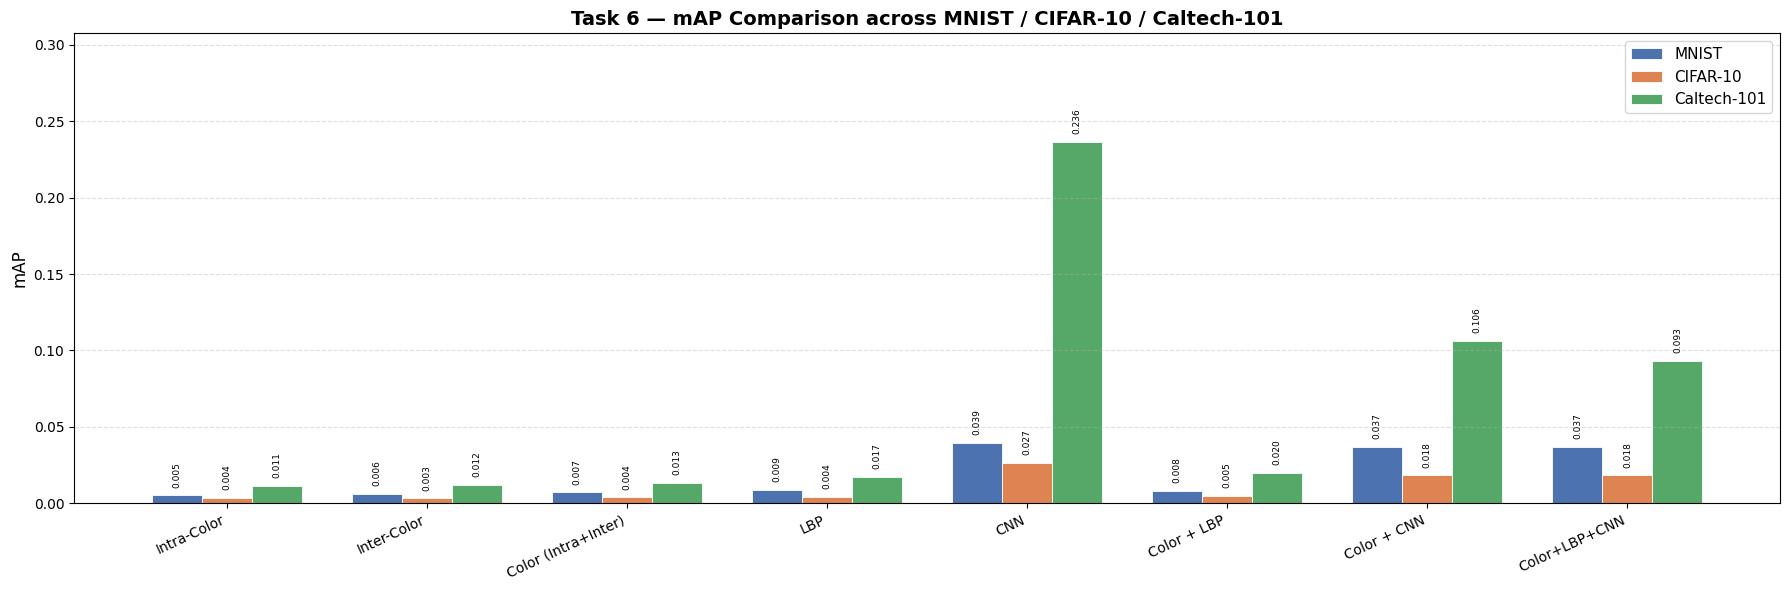

In [17]:
methods   = df_all['Method'].unique().tolist()
datasets  = ['MNIST', 'CIFAR-10', 'Caltech-101']
colors    = ['#4C72B0', '#DD8452', '#55A868']

x   = np.arange(len(methods))
w   = 0.25
off = [-w, 0, w]

fig, ax = plt.subplots(figsize=(18, 6))
for i, (ds, col) in enumerate(zip(datasets, colors)):
    vals = df_all[df_all['Dataset'] == ds]['mAP'].tolist()
    bars = ax.bar(x + off[i], vals, w, label=ds, color=col, edgecolor='white', linewidth=0.6)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('mAP', fontsize=12)
ax.set_title('Task 6 — mAP Comparison across MNIST / CIFAR-10 / Caltech-101', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, df_all['mAP'].max() * 1.3)
plt.tight_layout()
plt.savefig('task6_map_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

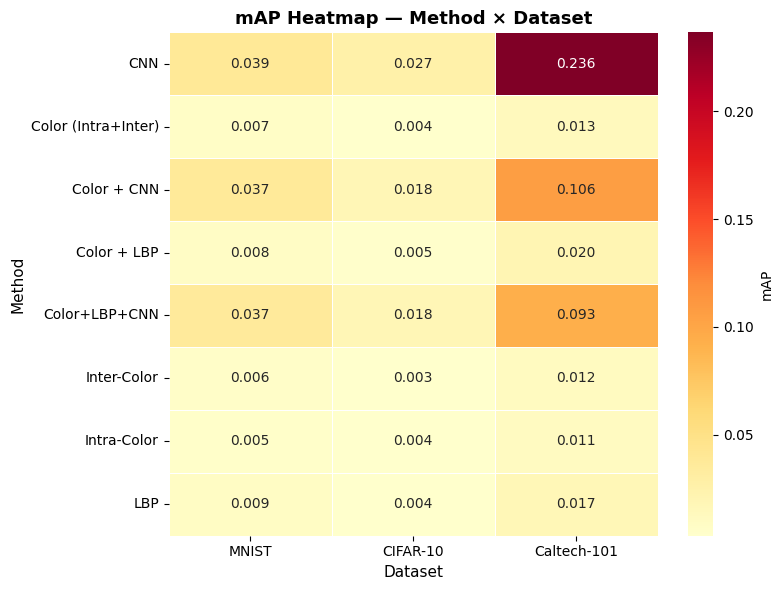

In [18]:
pivot = df_all.pivot(index='Method', columns='Dataset', values='mAP')
pivot = pivot[datasets]  # fix column order

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'mAP'}, ax=ax
)
ax.set_title('mAP Heatmap — Method × Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=11)
ax.set_ylabel('Method', fontsize=11)
plt.tight_layout()
plt.savefig('task6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

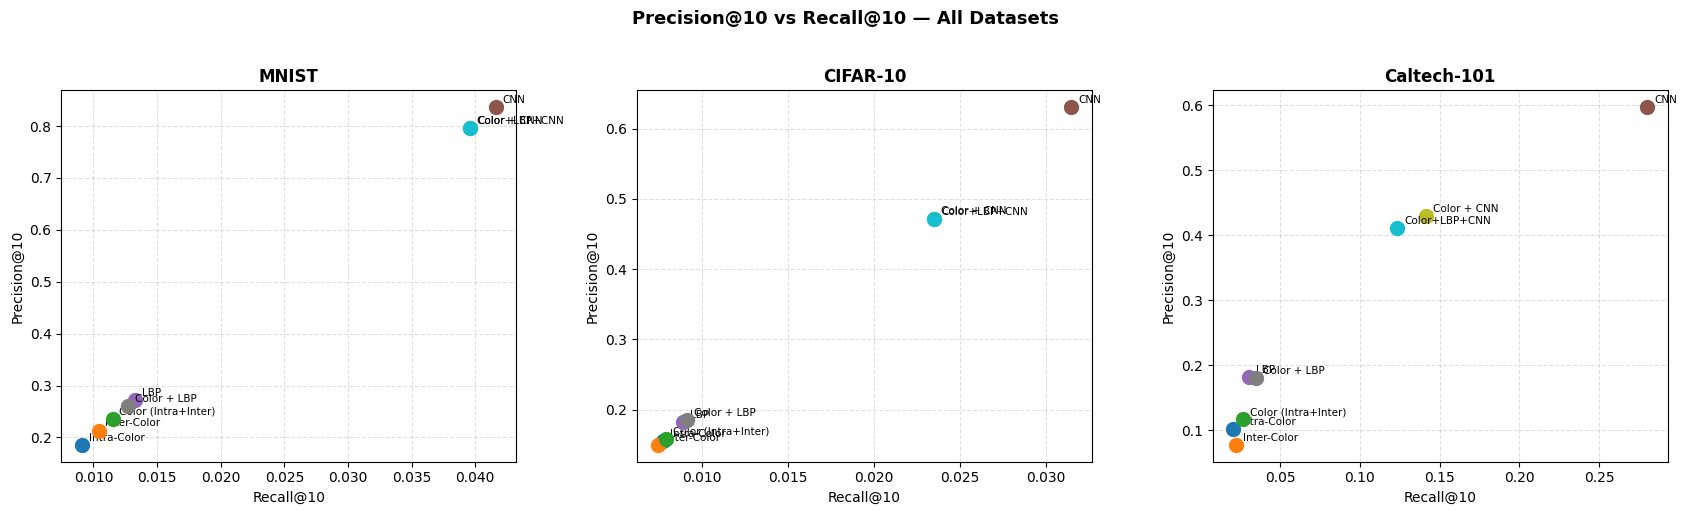

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
method_colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

for ax, ds in zip(axes, datasets):
    sub = df_all[df_all['Dataset'] == ds]
    for j, row in sub.iterrows():
        ax.scatter(row[f'Recall@{K}'], row[f'Precision@{K}'],
                   color=method_colors[methods.index(row['Method'])],
                   s=100, zorder=3)
        ax.annotate(row['Method'], (row[f'Recall@{K}'], row[f'Precision@{K}']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5)
    ax.set_title(ds, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Recall@{K}', fontsize=10)
    ax.set_ylabel(f'Precision@{K}', fontsize=10)
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle(f'Precision@{K} vs Recall@{K} — All Datasets', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task6_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

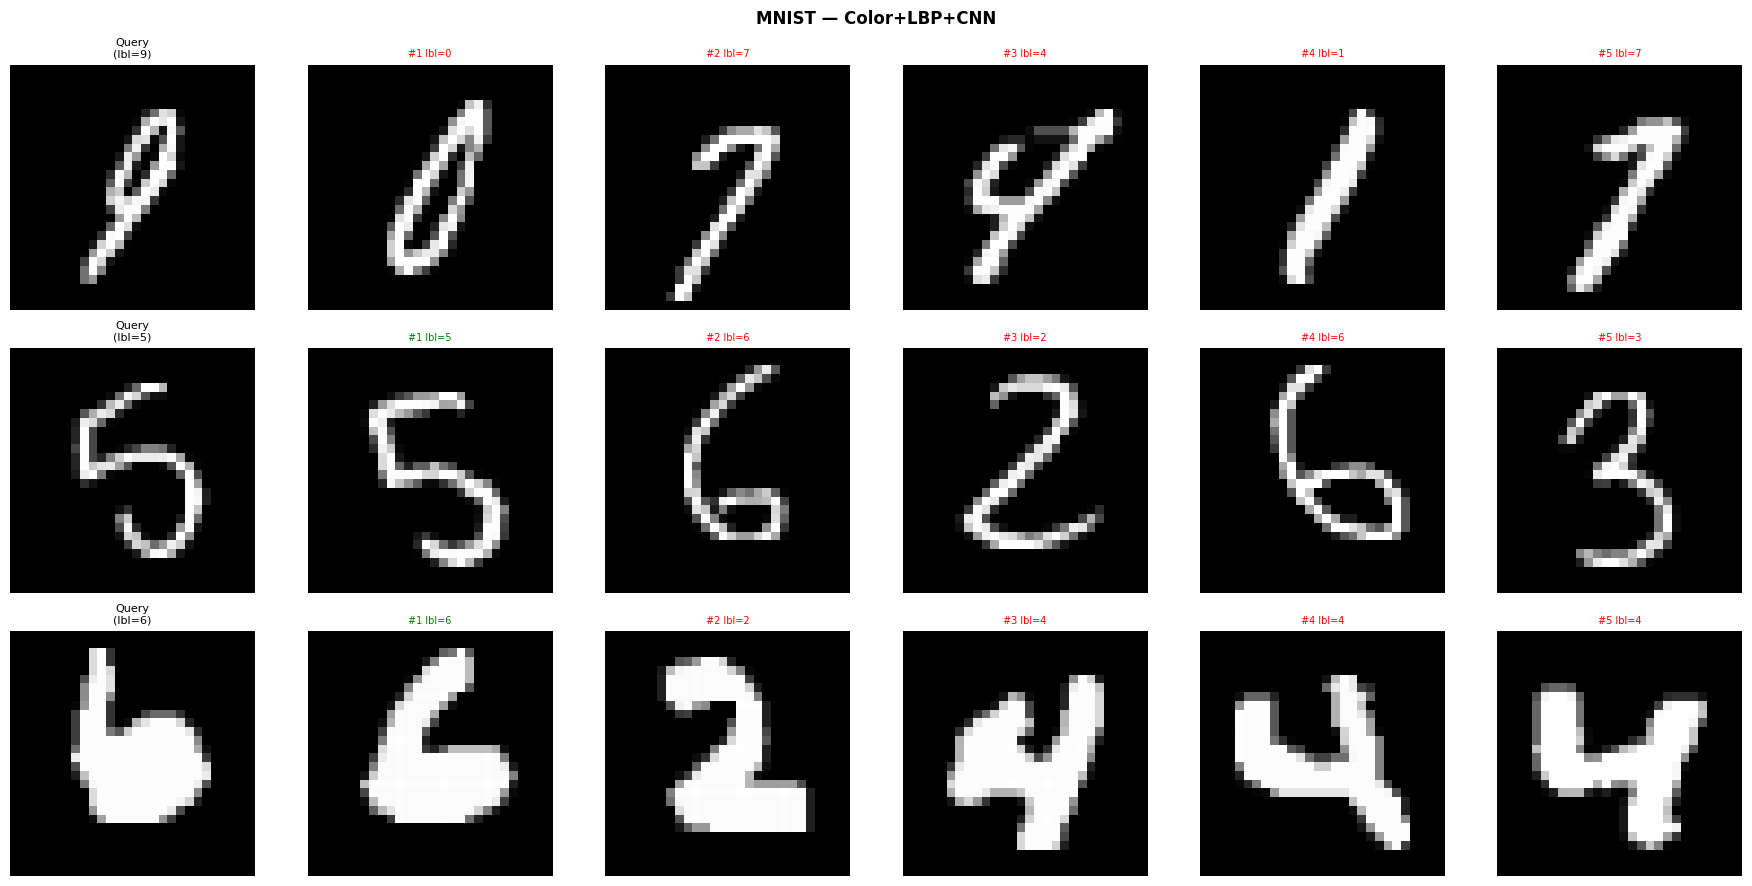

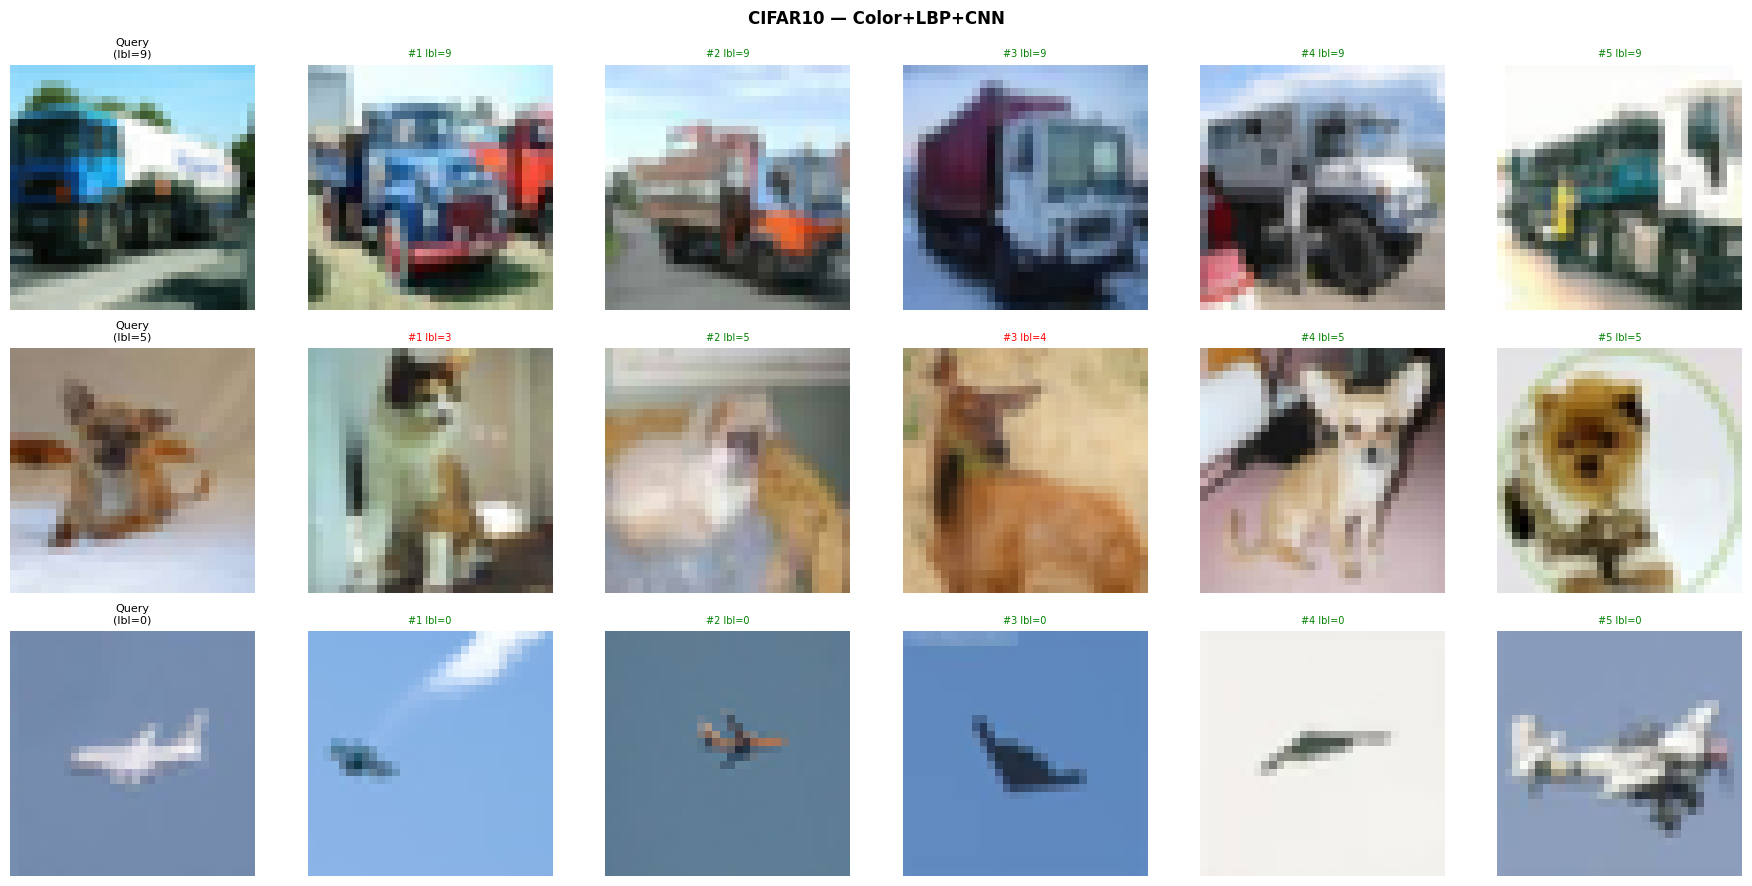

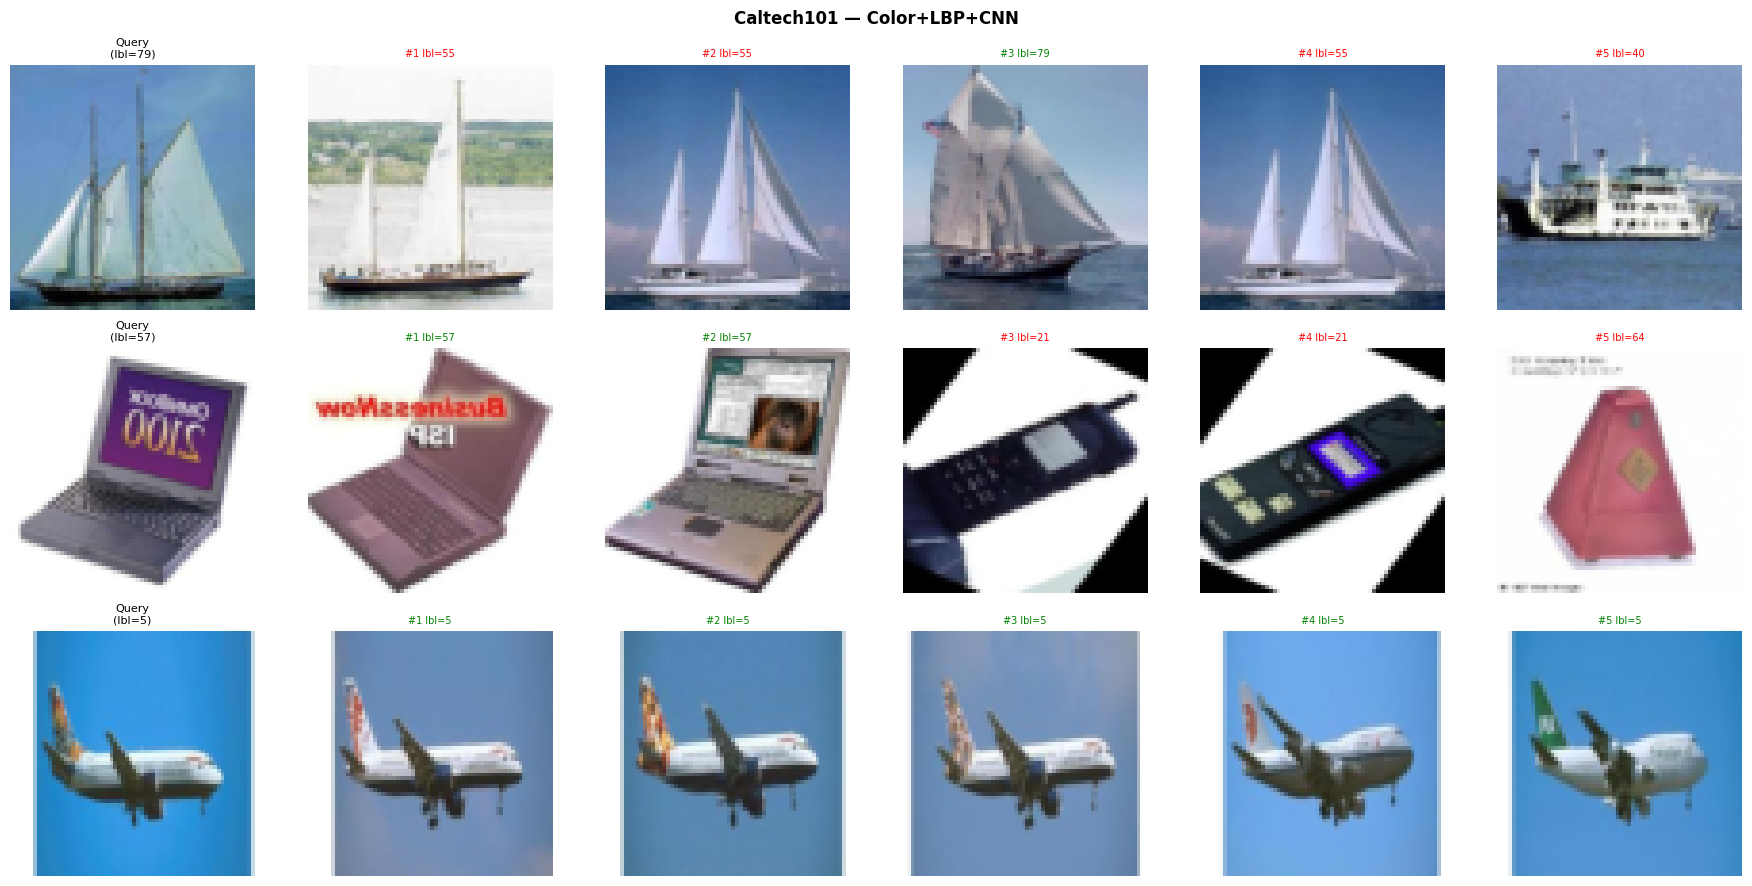

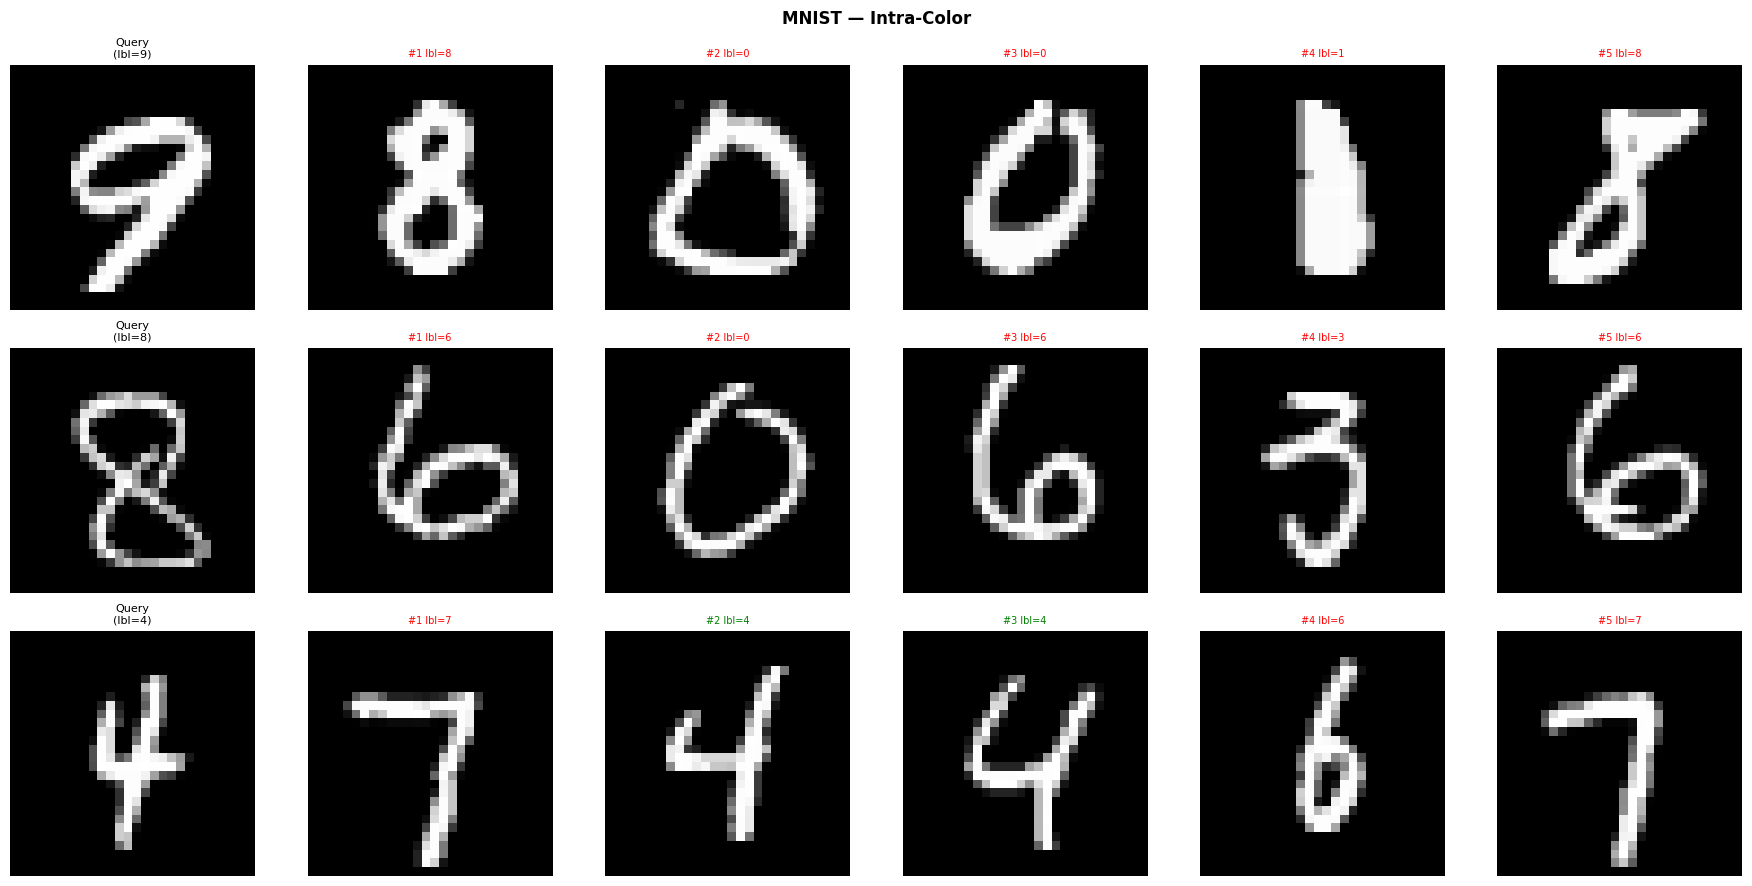

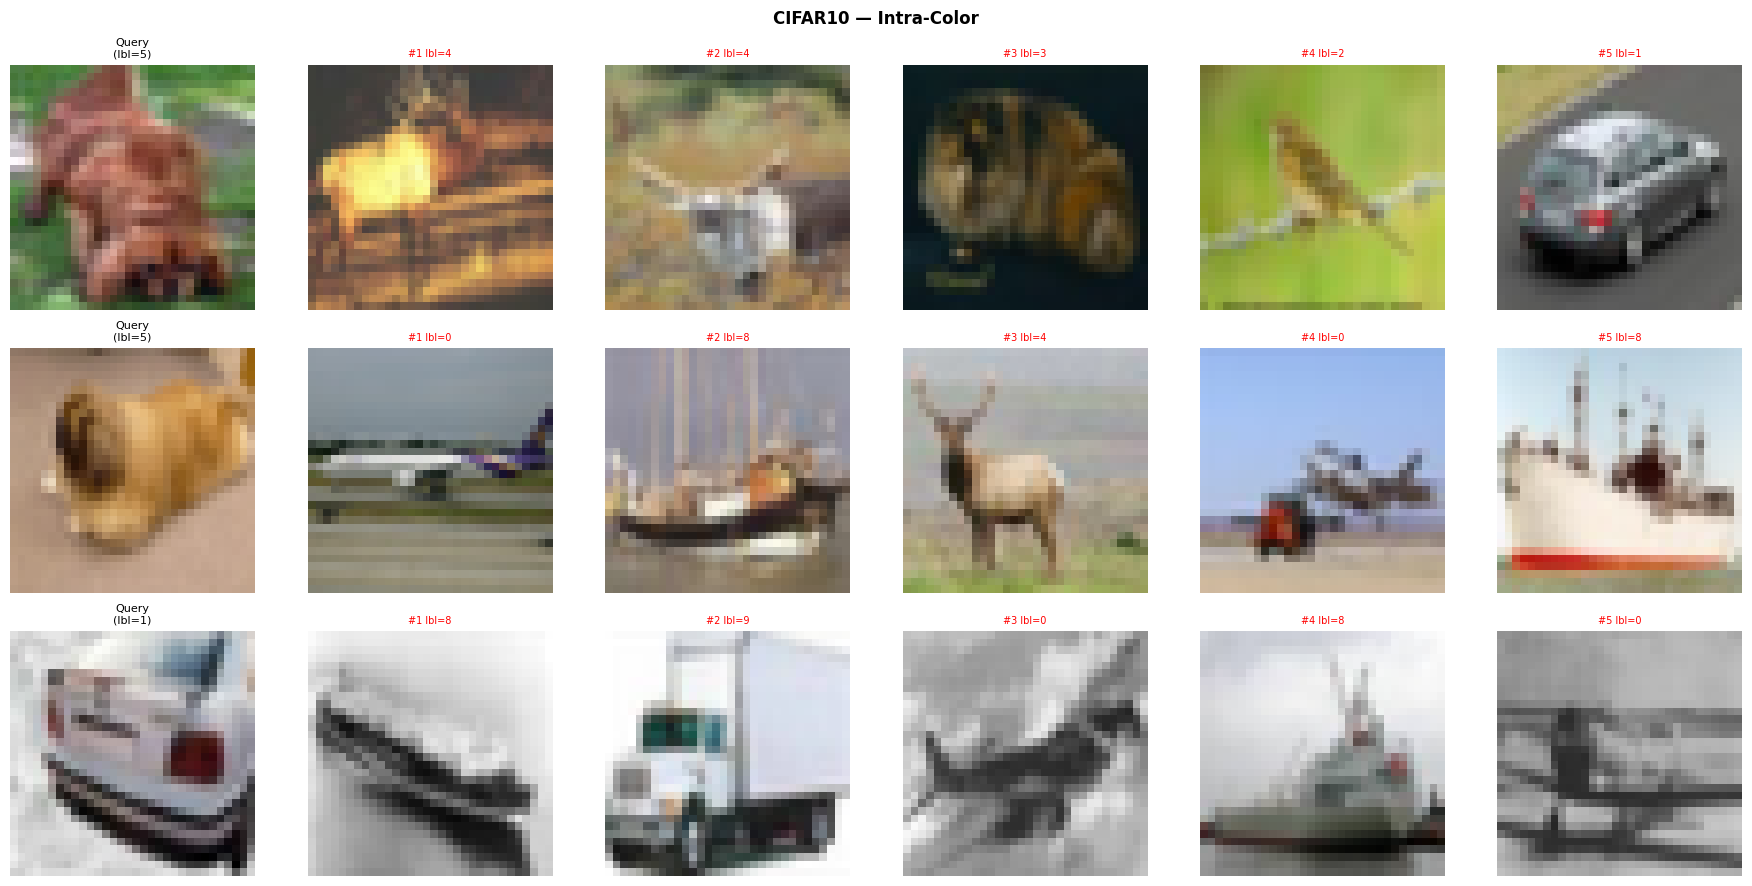

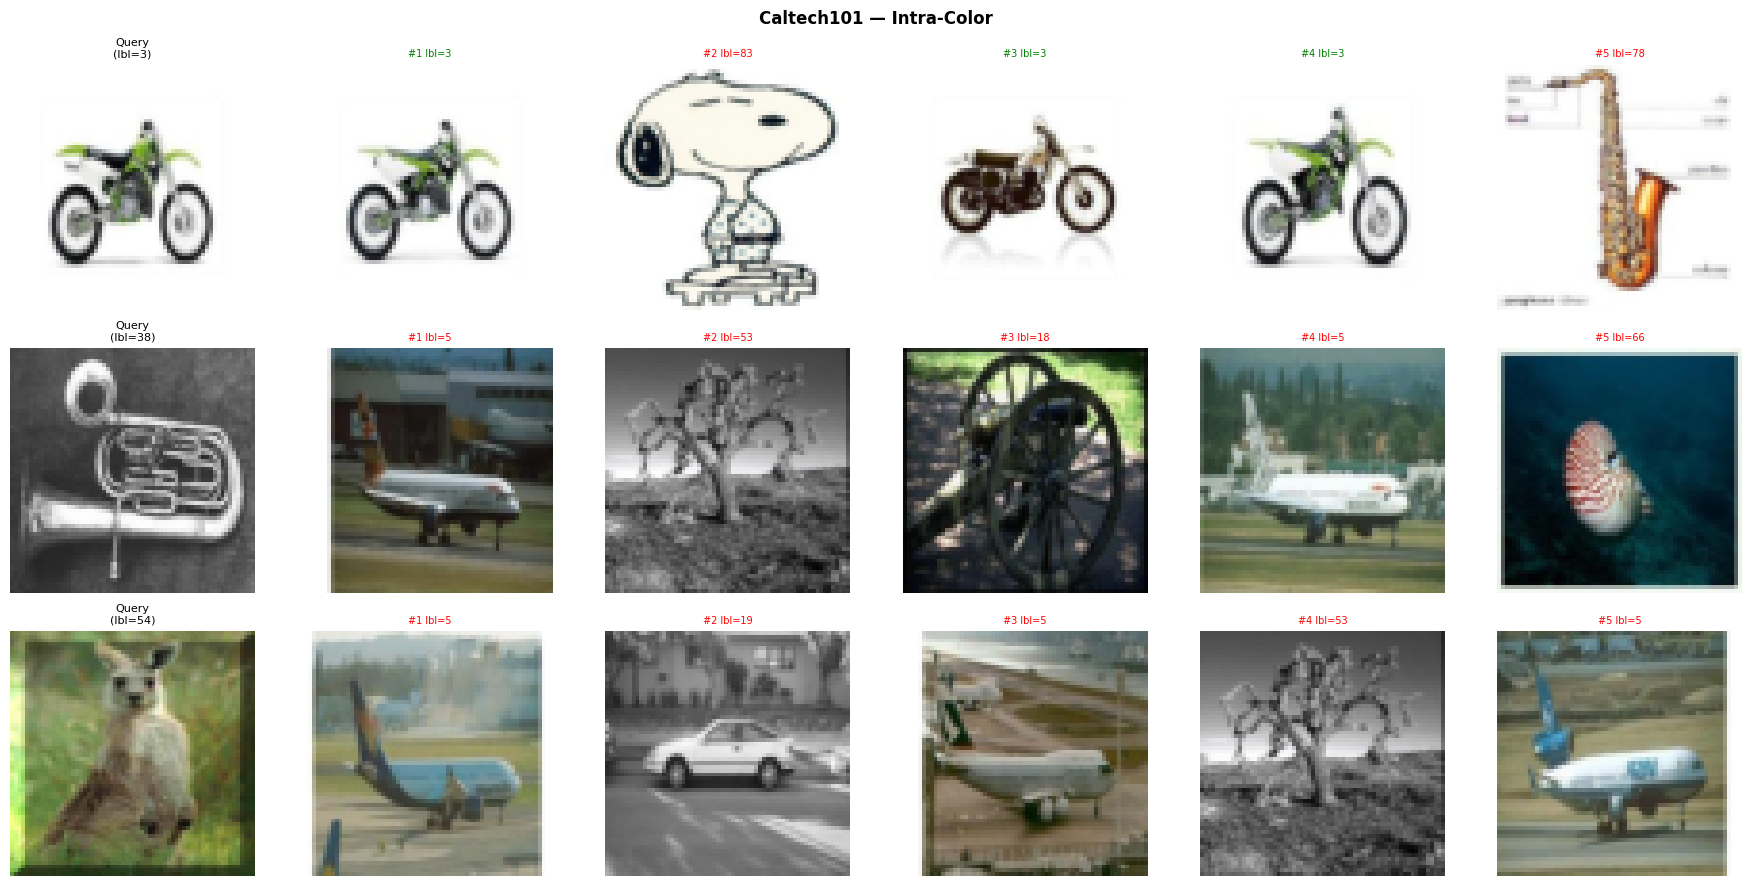

In [20]:
def show_retrieval(query_np, gallery_np, q_feat, g_feat, q_labels, g_labels,
                   title='', n_queries=3, k=5):
    idx = retrieve(q_feat, g_feat, k=k)
    fig, axes = plt.subplots(n_queries, k+1, figsize=(3*(k+1), 3*n_queries))
    if n_queries == 1:
        axes = [axes]

    qsel = np.random.choice(len(query_np), n_queries, replace=False)
    for row, qi in enumerate(qsel):
        # Query image
        axes[row][0].imshow(query_np[qi].clip(0,1))
        axes[row][0].set_title(f'Query\n(lbl={q_labels[qi]})', fontsize=8)
        axes[row][0].axis('off')
        axes[row][0].patch.set_edgecolor('blue')
        axes[row][0].patch.set_linewidth(4)
        # Retrieved
        for col, gi in enumerate(idx[qi]):
            axes[row][col+1].imshow(gallery_np[gi].clip(0,1))
            match = g_labels[gi] == q_labels[qi]
            axes[row][col+1].set_title(
                f'#{col+1} lbl={g_labels[gi]}', fontsize=7,
                color='green' if match else 'red'
            )
            axes[row][col+1].axis('off')

    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'task6_retrieval_{title.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

# Show for best (Color+LBP+CNN) and baseline (Intra-Color) on each dataset
for feat_name in ['Color+LBP+CNN', 'Intra-Color']:
    show_retrieval(Qm_np, Gm_np, Q_mnist[feat_name],   G_mnist[feat_name],   Qm_lbl, Gm_lbl, f'MNIST — {feat_name}')
    show_retrieval(Qc_np, Gc_np, Q_cifar[feat_name],   G_cifar[feat_name],   Qc_lbl, Gc_lbl, f'CIFAR10 — {feat_name}')
    show_retrieval(Qk_np, Gk_np, Q_caltech[feat_name], G_caltech[feat_name], Qk_lbl, Gk_lbl, f'Caltech101 — {feat_name}')

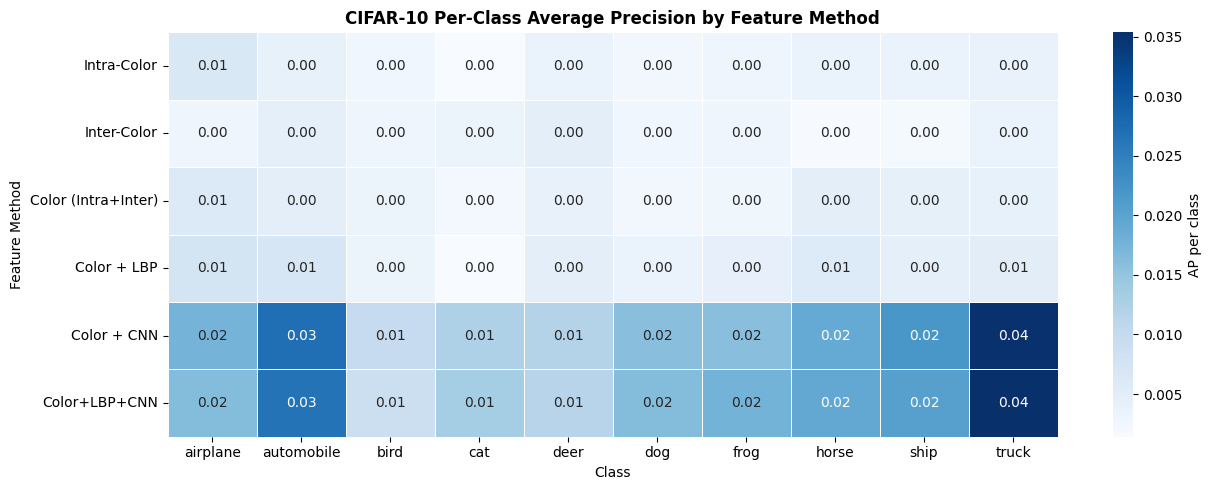

In [21]:
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def per_class_map(q_labels, g_labels, top_k_idx, n_classes, k=10):
    class_aps = {c: [] for c in range(n_classes)}
    for qi, ret in enumerate(top_k_idx):
        ql  = q_labels[qi]
        rel = (g_labels[ret] == ql).astype(int)
        tot = max((g_labels == ql).sum(), 1)
        ap = 0.0; nr = 0
        for rk, r in enumerate(rel, 1):
            if r: nr+=1; ap+=nr/rk
        class_aps[ql].append(ap/tot)
    return {c: np.mean(v) if v else 0.0 for c,v in class_aps.items()}

key_methods_cifar = ['Intra-Color','Inter-Color','Color (Intra+Inter)','Color + LBP','Color + CNN','Color+LBP+CNN']
heatmap_data = []
for m in key_methods_cifar:
    idx = retrieve(Q_cifar[m], G_cifar[m], k=K)
    cm  = per_class_map(Qc_lbl, Gc_lbl, idx, n_classes=10)
    heatmap_data.append([cm[c] for c in range(10)])

df_heat = pd.DataFrame(heatmap_data, index=key_methods_cifar, columns=CIFAR_CLASSES)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(df_heat, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, cbar_kws={'label':'AP per class'}, ax=ax)
ax.set_title('CIFAR-10 Per-Class Average Precision by Feature Method', fontsize=12, fontweight='bold')
ax.set_xlabel('Class', fontsize=10)
ax.set_ylabel('Feature Method', fontsize=10)
plt.tight_layout()
plt.savefig('task6_cifar_perclass_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Final Summary Print ───────────────────────────────────────────────────────
print('\n' + '='*100)
print('TASK 6 FINAL COMPARATIVE ANALYSIS — MNIST / CIFAR-10 / CALTECH-101')
print('='*100)
print(df_all.to_string(index=False))
print('='*100)

print('\nBest method per dataset (by mAP):')
for ds in datasets:
    sub  = df_all[df_all['Dataset'] == ds]
    best = sub.loc[sub['mAP'].idxmax()]
    print(f'  {ds:15s} → {best["Method"]:25s}  mAP={best["mAP"]:.4f}')


TASK 6 FINAL COMPARATIVE ANALYSIS — MNIST / CIFAR-10 / CALTECH-101
    Dataset              Method  Precision@10  Recall@10    mAP
      MNIST         Intra-Color        0.1857     0.0091 0.0052
      MNIST         Inter-Color        0.2133     0.0104 0.0064
      MNIST Color (Intra+Inter)        0.2363     0.0115 0.0073
      MNIST                 LBP        0.2727     0.0133 0.0089
      MNIST                 CNN        0.8363     0.0416 0.0394
      MNIST         Color + LBP        0.2610     0.0127 0.0082
      MNIST         Color + CNN        0.7967     0.0396 0.0371
      MNIST       Color+LBP+CNN        0.7957     0.0396 0.0370
   CIFAR-10         Intra-Color        0.1553     0.0077 0.0035
   CIFAR-10         Inter-Color        0.1497     0.0074 0.0033
   CIFAR-10 Color (Intra+Inter)        0.1587     0.0079 0.0039
   CIFAR-10                 LBP        0.1823     0.0089 0.0042
   CIFAR-10                 CNN        0.6303     0.0315 0.0267
   CIFAR-10         Color + LBP     